## The Data

To learn the basic syntax of Keras, we will use a very simple fake data set, let's focus on the syntax of TensorFlow 2.0.

Let's pretend this data are measurements of some rare gem stones, with 2 measurement features and a sale price. Our final goal would be to try to predict the sale price of a new gem stone we just mined from the ground, in order to try to set a fair price in the market.

### Load the Data

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('D:/5 month Learning/Python for Data Science/TensorFlow_FILES/TensorFlow_FILES/DATA/fake_reg.csv')

In [4]:
df.head()

,price,feature1,feature2
0,461.527929,999.787558,999.766096
1,548.130011,998.861615,1001.042403
2,410.297162,1000.070267,998.844015
3,540.382220,999.952251,1000.440940
4,546.024553,1000.446011,1000.338531


### Explore the data

Let's take a quick look, we should see strong correlation between the features and the "price" of this made up product.

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

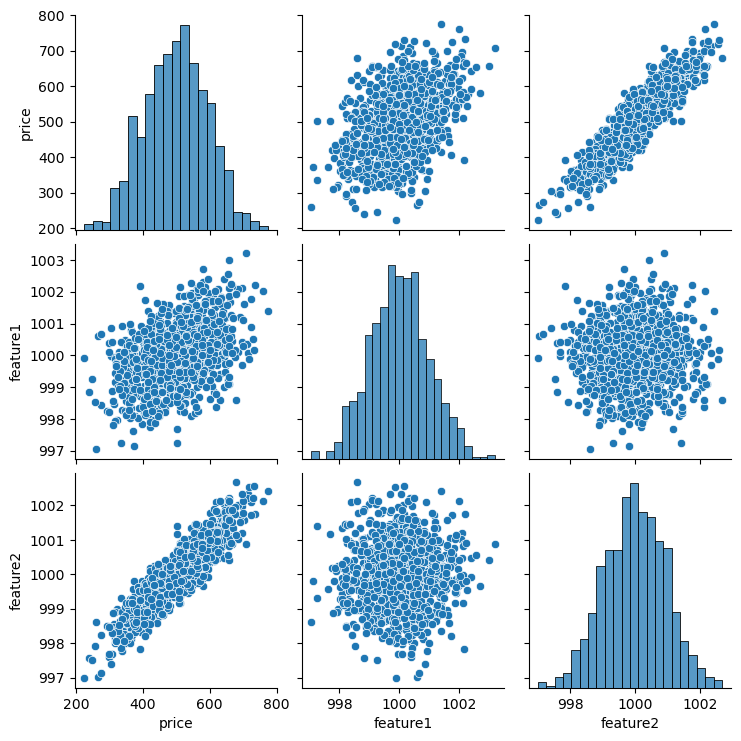

In [6]:
sns.pairplot(data=df)

### Test/Train Split

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
# convert pandas df to numpy for Keras

#features
X = df[['feature1','feature2']].values

#label
y = df['price'].values

#split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [10]:
X_train.shape

(700, 2)

In [11]:
X_test.shape

(300, 2)

## Normalizing/Scaling the Data

We scale the feature data, not the label

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
help(MinMaxScaler)

Help on class MinMaxScaler in module sklearn.preprocessing._data:

class MinMaxScaler(sklearn.base.OneToOneFeatureMixin, sklearn.base.TransformerMixin, sklearn.base.BaseEstimator)
 |  MinMaxScaler(feature_range=(0, 1), *, copy=True, clip=False)
 |
 |  Transform features by scaling each feature to a given range.
 |
 |  This estimator scales and translates each feature individually such
 |  that it is in the given range on the training set, e.g. between
 |  zero and one.
 |
 |  The transformation is given by::
 |
 |      X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
 |      X_scaled = X_std * (max - min) + min
 |
 |  where min, max = feature_range.
 |
 |  This transformation is often used as an alternative to zero mean,
 |  unit variance scaling.
 |
 |  `MinMaxScaler` doesn't reduce the effect of outliers, but it linearly
 |  scales them down into a fixed range, where the largest occurring data point
 |  corresponds to the maximum value and the smallest one corresponds to

In [15]:
#creating am instance of the minmax scaler 
scaler = MinMaxScaler()

To prevent data leakage from the test set, we only fit our scaler to the training set

In [16]:
scaler.fit(X_train)

MinMaxScaler()

In [17]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Creating a Model

There are two ways to create models through the TF 2 Keras API, either pass in a list of layers all at once, or add them one by one.
let us implement both the methods

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

### Model - as a list of layers

In [19]:
#unit defines the number of neurons per layer
model = Sequential([
    Dense(units=2),
    Dense(units=2),
    Dense(units=2)
])

### Model - adding in layers one by one

In [20]:
model = Sequential()

model.add(Dense(4, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(4, activation='relu'))

#Final output layer for prediction
model.add(Dense(1))

model.compile(optimizer='rmsprop',loss='mse')


### Choosing an optimizer and loss


    # For a multi-class classification problem
    model.compile(optimizer='rmsprop' or 'adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # For a binary classification problem
    model.compile(optimizer='rmsprop' or 'adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    # For a mean squared error regression problem
    model.compile(optimizer='rmsprop' or 'adam',
                  loss='mse')

# Training

Below are some common definitions that are necessary to know and understand to correctly utilize Keras:

* Sample: one element of a dataset.
    * Example: one image is a sample in a convolutional network
    * Example: one audio file is a sample for a speech recognition model
* Batch: a set of N samples. The samples in a batch are processed independently, in parallel. If training, a batch results in only one update to the model.A batch generally approximates the distribution of the input data better than a single input. The larger the batch, the better the approximation; however, it is also true that the batch will take longer to process and will still result in only one update. For inference (evaluate/predict), it is recommended to pick a batch size that is as large as you can afford without going out of memory (since larger batches will usually result in faster evaluation/prediction).
* Epoch: an arbitrary cutoff, generally defined as "one pass over the entire dataset", used to separate training into distinct phases, which is useful for logging and periodic evaluation.
* When using validation_data or validation_split with the fit method of Keras models, evaluation will be run at the end of every epoch.
* Within Keras, there is the ability to add callbacks specifically designed to be run at the end of an epoch. Examples of these are learning rate changes and model checkpointing (saving).

In [21]:
model.fit(X_train, y_train, epochs=250)

Epoch 1/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 256629.2812
Epoch 2/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 256500.1094
Epoch 3/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 256367.9375 
Epoch 4/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 256214.0625
Epoch 5/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 256038.2656 
Epoch 6/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 255839.4219
Epoch 7/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 255615.1250 
Epoch 8/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 255364.6094
Epoch 9/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 255088.8281 
Epoch 10/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 254784.3438
Epoch 11/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 254447.7188
Epoch 12/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 254082.6719 
Epoch 13/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 253685.2188 
Epoch 14/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 253253.

## Evaluation

Let's evaluate our performance on our training set and our test set. We can compare these two performances to check for overfitting.

In [23]:
#to show the loss history
model.history.history

{'loss': [256629.28125,
  256500.109375,
  256367.9375,
  256214.0625,
  256038.265625,
  255839.421875,
  255615.125,
  255364.609375,
  255088.828125,
  254784.34375,
  254447.71875,
  254082.671875,
  253685.21875,
  253253.375,
  252779.71875,
  252259.75,
  251688.984375,
  251064.0625,
  250386.828125,
  249648.703125,
  248848.34375,
  247986.421875,
  247052.734375,
  246054.953125,
  244976.203125,
  243818.515625,
  242587.75,
  241270.03125,
  239866.921875,
  238367.125,
  236779.171875,
  235094.359375,
  233309.546875,
  231415.609375,
  229411.3125,
  227297.375,
  225074.234375,
  222751.25,
  220304.34375,
  217717.09375,
  215020.546875,
  212204.984375,
  209243.71875,
  206149.828125,
  202941.421875,
  199603.515625,
  196155.65625,
  192545.25,
  188790.390625,
  184912.890625,
  180899.640625,
  176756.453125,
  172497.8125,
  168082.65625,
  163545.625,
  158904.421875,
  154140.21875,
  149242.703125,
  144276.28125,
  139145.875,
  133926.1875,
  128619.5625,


In [24]:
loss = model.history.history['loss']

Text(0.5, 1.0, 'Training Loss per Epoch')

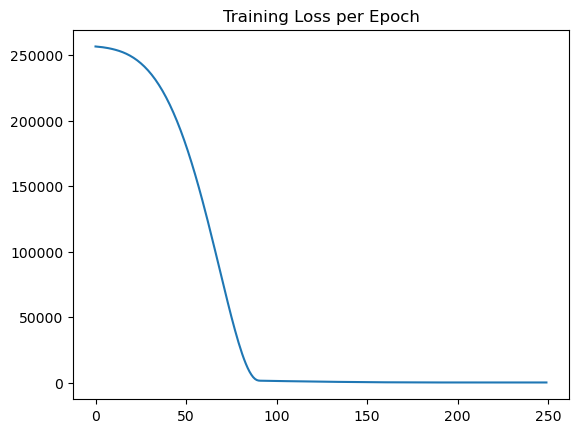

In [26]:
sns.lineplot(x=range(len(loss)),y=loss)
plt.title("Training Loss per Epoch")

### Compare final evaluation (MSE) on training set and test set.

In [27]:
model.metrics_names

['loss']

In [28]:
#mse is used as evaluation criteria 
training_score = model.evaluate(X_train, y_train, verbose = 0)
testing_score = model.evaluate(X_test, y_test, verbose = 0)

In [31]:
#will show the training loss
training_score

24.455102920532227

In [33]:
#will show the testing loss
testing_score

26.623308181762695

In [34]:
#doing predictions on the test data
test_predictions = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [35]:
test_predictions

array([[406.2225 ],
       [625.0025 ],
       [593.5296 ],
       [573.5387 ],
       [367.40625],
       [580.52716],
       [516.2042 ],
       [460.19055],
       [550.5028 ],
       [448.57855],
       [613.2215 ],
       [550.27637],
       [420.06256],
       [409.7998 ],
       [652.82355],
       [438.3238 ],
       [509.67657],
       [661.44104],
       [664.1234 ],
       [566.87933],
       [334.96265],
       [445.8598 ],
       [383.38544],
       [379.62567],
       [567.9165 ],
       [611.99817],
       [533.62524],
       [428.85272],
       [656.9558 ],
       [415.0551 ],
       [443.67892],
       [486.25513],
       [439.43158],
       [683.43085],
       [425.77032],
       [418.62854],
       [503.1479 ],
       [551.76526],
       [510.8824 ],
       [396.2193 ],
       [620.0534 ],
       [417.6034 ],
       [605.8753 ],
       [447.02673],
       [503.15625],
       [583.1312 ],
       [670.61444],
       [491.56195],
       [319.3238 ],
       [486.55048],


In [36]:
#creating a dataframe on the actual testing data
pred_df = pd.DataFrame(y_test, columns = ['Test Y'])


In [37]:
pred_df

,Test Y
0,402.296319
1,624.156198
2,582.455066
3,578.588606
4,371.224104
...,...
295,525.704657
296,502.909473
297,612.727910
298,417.569725


In [38]:
#reshape converts to 1D array
test_predictions = pd.Series(test_predictions.reshape(300,))

In [39]:
test_predictions

0      406.222504
1      625.002502
2      593.529602
3      573.538696
4      367.406250
          ...    
295    530.256470
296    516.451172
297    611.086426
298    417.939331
299    411.803345
Length: 300, dtype: float32

In [40]:
#concatening new column to pred_df for the predictions
pred_df = pd.concat([pred_df, test_predictions], axis = 1)

In [41]:
pred_df.head()

,Test Y,0
0,402.296319,406.222504
1,624.156198,625.002502
2,582.455066,593.529602
3,578.588606,573.538696
4,371.224104,367.406250


In [42]:
#renaming the column
pred_df.columns = ['Test Y','Model Predictions']

In [43]:
pred_df

,Test Y,Model Predictions
0,402.296319,406.222504
1,624.156198,625.002502
2,582.455066,593.529602
3,578.588606,573.538696
4,371.224104,367.406250
...,...,...
295,525.704657,530.256470
296,502.909473,516.451172
297,612.727910,611.086426
298,417.569725,417.939331


Let's compare to the real test labels!

<Axes: xlabel='Test Y', ylabel='Model Predictions'>

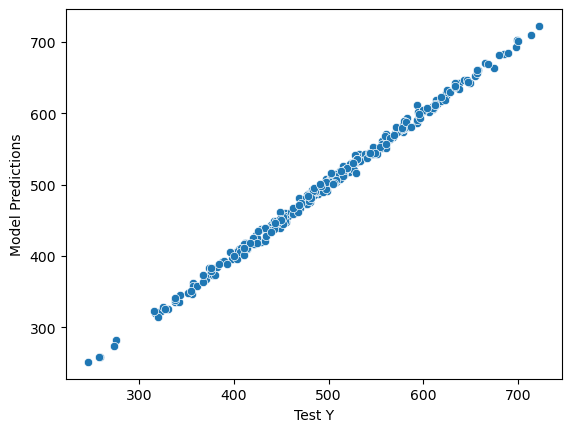

In [44]:
#plotting scatter plot  between the real and predicted , if it is a straight line, it shows a good model 
sns.scatterplot(x='Test Y', y='Model Predictions', data=pred_df)

In [46]:
pred_df['Error'] = pred_df['Test Y'] - pred_df['Model Predictions']

<Axes: xlabel='Error', ylabel='Count'>

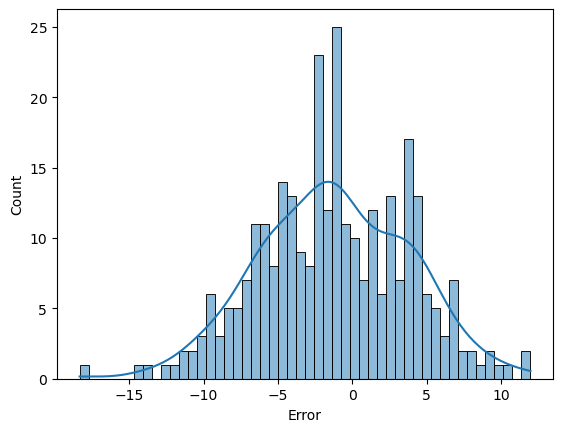

In [48]:
# plotting the histogram of the error
sns.histplot(pred_df['Error'], bins = 50, kde=True)

In [50]:
from sklearn.metrics import mean_absolute_error,  mean_squared_error

In [51]:
#mean absolute error
mean_absolute_error(pred_df['Test Y'], pred_df['Model Predictions'])

4.182260590208251

In [52]:
#mean squared error
mean_squared_error(pred_df['Test Y'], pred_df['Model Predictions'])

26.623308809251

# Predicting on brand new data

What if we just saw a brand new gemstone from the ground? What should we price it at? This is the **exact** same procedure as predicting on a new test data!

In [70]:
# [[Feature1, Feature2]]
new_gem = [[998,1000]]

In [71]:
#since our model is trained on scaled data
new_gem = scaler.transform(new_gem)

In [72]:
#predictions for the new data 
model.predict(new_gem)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([[420.60867]], dtype=float32)

## Saving and Loading a Model

In [73]:
from tensorflow.keras.models import load_model

In [77]:
model.save('my_model.keras')

In [78]:
later_model = load_model('my_model.keras')

In [80]:
later_model.predict(new_gem)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


array([[420.60867]], dtype=float32)